In [1]:
import cafe
import scanpy as sc

cafe.settings.backend = "python_function"
cafe.logger.setLevel("DEBUG")
import pandas as pd
import numpy as np
from cafe.data import FateAnnData
from cafe.metric.metric_correlation_v2 import calculate_correlation
from cafe.metric.metric_position_predict_v2 import calculate_position_predict
from cafe.metric.metric_featureimp_v2 import (
    calculate_overall_feature_importance,
    calculate_featureimp_cor,
    calculate_featureimp_enrichment,
    fi_ranger_rf_tiny,
)
from cafe.metric.cluster_metric_v2 import calculate_mapping_branches, calculate_mapping_milestones, calculate_mapping
from cafe.metric._topology_metric.metric_him import calculate_him
from cafe.metric.topology_metric import calc_isomorphic, calculate_edge_flip

[2025年04月24日 16时59分31秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据读取

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cafe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"

sc.pp.subsample(fadata, n_obs=500)

fadata

                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      
                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      


AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
    ],
    columns=["from", "to"],
)

fadata.add_trajectory_mannually(milestone_network)

                        DEBUG    FateAnnData add_trajectory                                                        


[2025年04月24日 16时59分33秒] DEBUG    plot_trajectory                                                             
                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年04月24日 16时59分34秒] DEBUG    add waypoints shape is (210, 500), finished!                                


<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

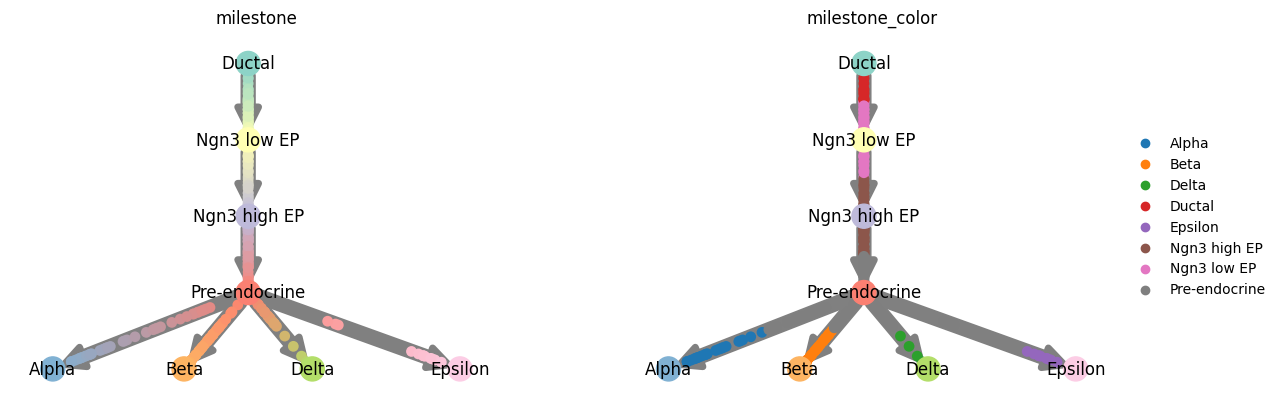

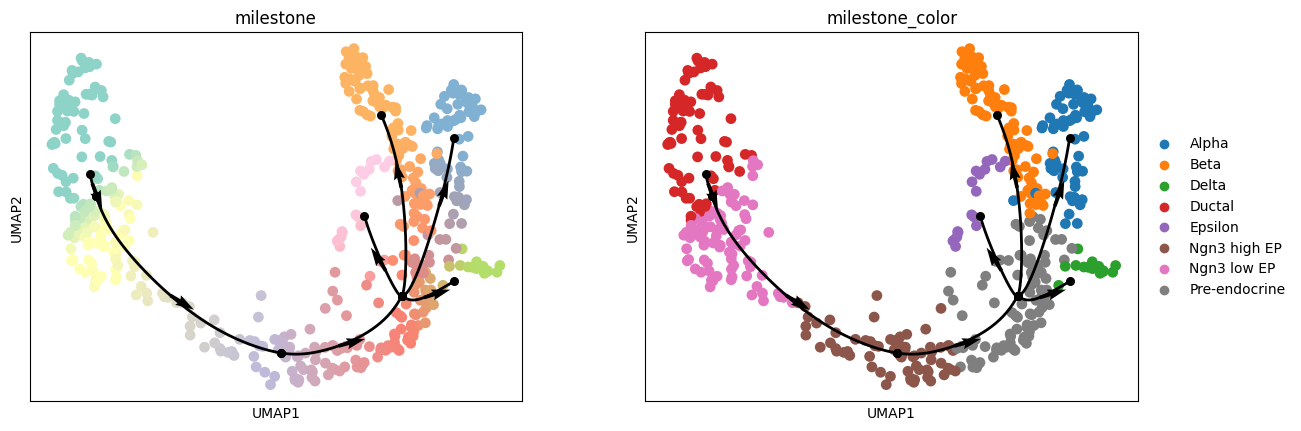

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color

cluster_key_list = ["milestone", cluster_key]
cafe.plot.plot_graph(fadata, color=cluster_key_list)
cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年04月24日 16时59分37秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x7746997edbd0> from                       
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_comp1.py                   
                        INFO     method_backend: <cafe.method.fate_function_backend.FunctionBackend object at       
                                 0x7745fc721d20>                                                                   
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                                                   
                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                   

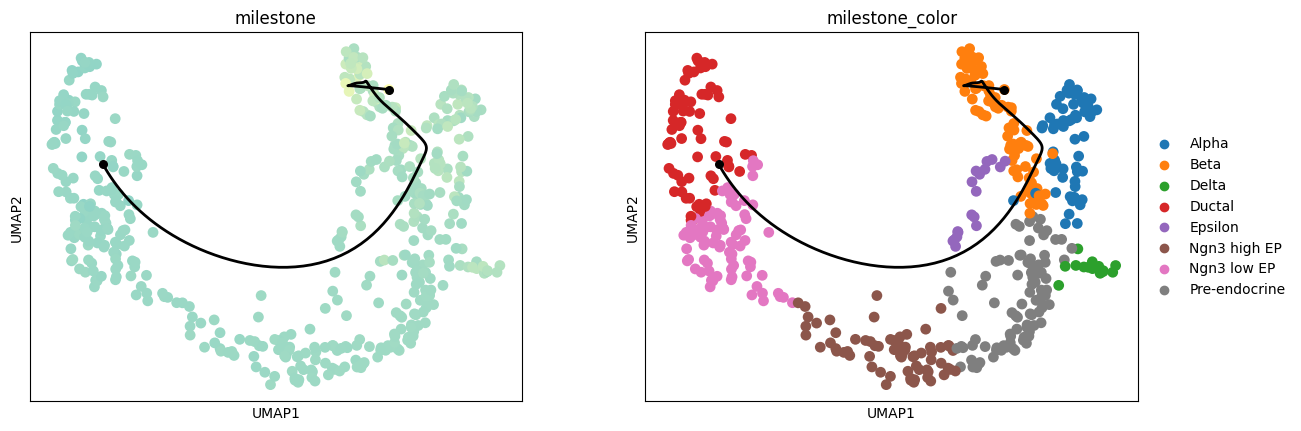

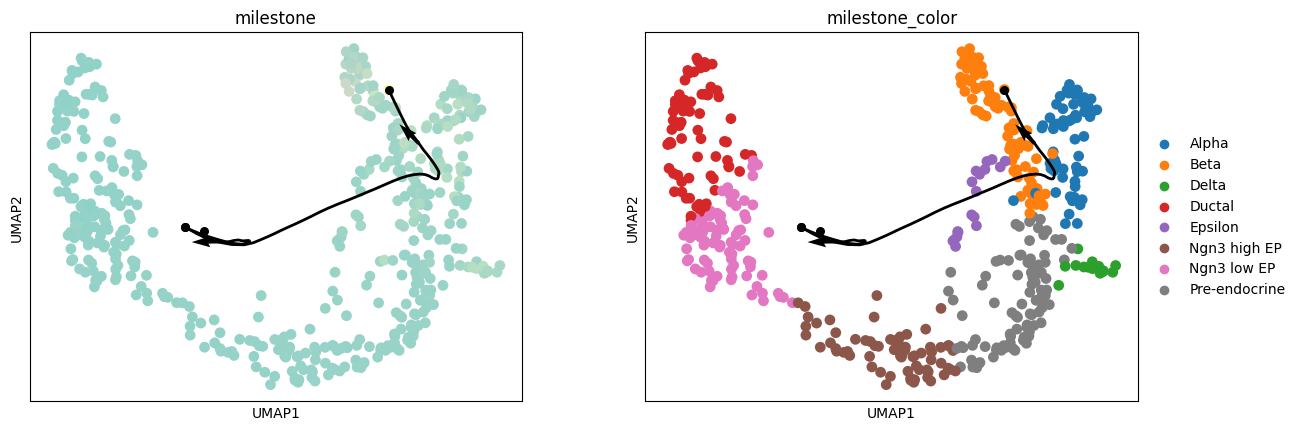

In [5]:
# TODO: PAGA need to be optimized, disconnected graph
prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


# method_name_list = ["paga", "comp1", "angle", "state_comp", "cluster_mst", "projection_mst", "graph_mst", "scvelo"]
# method_name_list = ["comp1", "angle", "state_comp","paga","cluster_mst","projection_mst","graph_mst"]
# method_name_list = ["comp1", "state_comp","paga","cluster_mst","projection_mst","graph_mst"]
method_name_list = ["comp1", "state_comp"]

for method_name in method_name_list:
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata)
    cafe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

构造新的fadata(给代码打补丁)

In [12]:
new_fadata = cafe.data.FateAnnData(X=fadata.X, obs=fadata.obs, uns=fadata.uns)
# new_fadata = fadata.copy()

# import copy
# new_fadata = copy.deepcopy(fadata)
new_fadata

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_colors', 'milestone_color_colors', 'milestone_color_dict'

查看模型名称

In [13]:
parsed_model_name_list = fadata.get_all_model_name()  # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[2025年04月24日 17时00分15秒] WARNING  'ref' is not a valid random_time_string, don't need parse                   


(['ref', 'comp1-python_function', 'state_comp-python_function'],
 ['ref',
  '20250424_165937__comp1-python_function__kIppa4AooP',
  '20250424_165938__state_comp-python_function__vwjwqrpDl4'])

输出模型对应的MilestoneWrapper,并给新的new_fadata添加信息

In [14]:
for i in model_name_list:
    print(f"{i} : {fadata.trajectory_history_dict[i]['milestone_wrapper']}")
    new_fadata.model_name = i
    new_fadata.milestone_wrapper = fadata.trajectory_history_dict[i]["milestone_wrapper"]
    print(f"milestonenetwork is\n {new_fadata.milestone_wrapper['milestone_network']}")
    print(f"progressions is\n {new_fadata.milestone_wrapper['progressions']}")

ref : <cafe.data.fate_milestone_wrapper.MilestoneWrapper object at 0x7745e9d41660>
milestonenetwork is
             from             to    length  directed
0         Ductal    Ngn3 low EP  1.671231      True
1    Ngn3 low EP   Ngn3 high EP  8.994165      True
2   Ngn3 high EP  Pre-endocrine  6.586894      True
3  Pre-endocrine          Alpha  6.210582      True
4  Pre-endocrine           Beta  6.141845      True
5  Pre-endocrine          Delta  3.911559      True
6  Pre-endocrine        Epsilon  4.122478      True
progressions is
              cell_id           from           to  percentage
0   AGCGGTCGTGTATGGG         Ductal  Ngn3 low EP    0.199266
1   TTCTCCTCACAGACTT         Ductal  Ngn3 low EP    0.000000
2   CAGCAGCAGACACGAC         Ductal  Ngn3 low EP    1.000000
3   CGTGTAATCTTTAGTC         Ductal  Ngn3 low EP    0.000000
4   CTGCTGTGTCTTTCAT         Ductal  Ngn3 low EP    0.139954
..               ...            ...          ...         ...
13  CCTTACGAGAGATGAG  Pre-endocrine 

检查new_fadata结构

In [15]:
new_fadata.uns["cfe"]

{'prior_information': {},
 'trajectory_history_dict': {'ref': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x7745e9d41660>},
  '20250424_165937__comp1-python_function__kIppa4AooP': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x7745ea2efe20>},
  '20250424_165938__state_comp-python_function__vwjwqrpDl4': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x7745d552b220>}}}

In [16]:
new_fadata.uns["cfe"]["trajectory_history_dict"]

{'ref': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x7745e9d41660>},
 '20250424_165937__comp1-python_function__kIppa4AooP': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x7745ea2efe20>},
 '20250424_165938__state_comp-python_function__vwjwqrpDl4': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x7745d552b220>}}

In [17]:
prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
new_fadata.add_prior_information(**prior_information)  # add prior information to fadata

In [18]:
new_fadata.uns["cfe"]

{'prior_information': {'start_id': 'AGCGGTCGTGTATGGG',
  'groups_id': ['Ductal',
   'Pre-endocrine',
   'Pre-endocrine',
   'Ductal',
   'Beta',
   'Alpha',
   'Beta',
   'Ngn3 low EP',
   'Ductal',
   'Ductal',
   'Ductal',
   'Pre-endocrine',
   'Ngn3 high EP',
   'Ngn3 high EP',
   'Ngn3 low EP',
   'Alpha',
   'Beta',
   'Ngn3 low EP',
   'Alpha',
   'Ngn3 low EP',
   'Ngn3 low EP',
   'Pre-endocrine',
   'Ductal',
   'Delta',
   'Ductal',
   'Ngn3 low EP',
   'Ngn3 low EP',
   'Beta',
   'Ngn3 low EP',
   'Beta',
   'Beta',
   'Ngn3 high EP',
   'Ngn3 low EP',
   'Alpha',
   'Beta',
   'Ductal',
   'Alpha',
   'Pre-endocrine',
   'Alpha',
   'Ngn3 low EP',
   'Ngn3 high EP',
   'Alpha',
   'Delta',
   'Ngn3 high EP',
   'Pre-endocrine',
   'Pre-endocrine',
   'Ductal',
   'Alpha',
   'Ngn3 high EP',
   'Pre-endocrine',
   'Ductal',
   'Ngn3 high EP',
   'Beta',
   'Pre-endocrine',
   'Ductal',
   'Pre-endocrine',
   'Alpha',
   'Beta',
   'Beta',
   'Ngn3 low EP',
   'Beta',
   'N

In [19]:
new_fadata.prior_information

{'start_id': 'AGCGGTCGTGTATGGG',
 'groups_id': ['Ductal',
  'Pre-endocrine',
  'Pre-endocrine',
  'Ductal',
  'Beta',
  'Alpha',
  'Beta',
  'Ngn3 low EP',
  'Ductal',
  'Ductal',
  'Ductal',
  'Pre-endocrine',
  'Ngn3 high EP',
  'Ngn3 high EP',
  'Ngn3 low EP',
  'Alpha',
  'Beta',
  'Ngn3 low EP',
  'Alpha',
  'Ngn3 low EP',
  'Ngn3 low EP',
  'Pre-endocrine',
  'Ductal',
  'Delta',
  'Ductal',
  'Ngn3 low EP',
  'Ngn3 low EP',
  'Beta',
  'Ngn3 low EP',
  'Beta',
  'Beta',
  'Ngn3 high EP',
  'Ngn3 low EP',
  'Alpha',
  'Beta',
  'Ductal',
  'Alpha',
  'Pre-endocrine',
  'Alpha',
  'Ngn3 low EP',
  'Ngn3 high EP',
  'Alpha',
  'Delta',
  'Ngn3 high EP',
  'Pre-endocrine',
  'Pre-endocrine',
  'Ductal',
  'Alpha',
  'Ngn3 high EP',
  'Pre-endocrine',
  'Ductal',
  'Ngn3 high EP',
  'Beta',
  'Pre-endocrine',
  'Ductal',
  'Pre-endocrine',
  'Alpha',
  'Beta',
  'Beta',
  'Ngn3 low EP',
  'Beta',
  'Ngn3 low EP',
  'Pre-endocrine',
  'Ductal',
  'Ductal',
  'Beta',
  'Ngn3 low EP',
 

指标部分

In [20]:
metrics = cafe.metric.metrics

topology指标

neighbourhood指标

In [21]:
for i in model_name_list:
    print(
        calculate_position_predict(
            new_fadata,
            "ref",
            i,
        )
    )

{'summary': {'rf_mse': 1.9905740879434183e-06, 'rf_rsq': 0.9999590629974948, 'rf_nmse': 0.9999752338697607, 'lm_mse': 5.738143120809038e-31, 'lm_rsq': 1.0, 'lm_nmse': 1.0}, 'rf_mses': {'Alpha': 1.8074908544397616e-06, 'Beta': 2.082702124380023e-06, 'Delta': 4.936076567580517e-06, 'Ductal': 1.5011995487290838e-06, 'Epsilon': 1.7586785968400073e-06, 'Ngn3 high EP': 1.6570963713082847e-06, 'Ngn3 low EP': 1.4519704451381401e-06, 'Pre-endocrine': 7.293781951315276e-07}, 'rf_rsqs': {'Alpha': 0.9999805044125876, 'Beta': 0.9999818696036331, 'Delta': 0.9998256161811436, 'Ductal': 0.999986606440106, 'Epsilon': 0.9999424021127715, 'Ngn3 high EP': 0.9999778926945615, 'Ngn3 low EP': 0.999986578278776, 'Pre-endocrine': 0.9999910342563785}, 'lm_rsqs': {'Alpha': 1.0, 'Beta': 1.0, 'Delta': 1.0, 'Ductal': 1.0, 'Epsilon': 1.0, 'Ngn3 high EP': 1.0, 'Ngn3 low EP': 1.0, 'Pre-endocrine': 1.0}}
{'summary': {'rf_mse': 0.008934129018961809, 'rf_rsq': 0.8715105947928075, 'rf_nmse': 0.8888442262971994, 'lm_mse': 

In [1]:
for i in model_name_list:
    print(calculate_featureimp_cor(new_fadata, "ref", i, new_fadata.X, fi_ranger_rf_tiny()))
    print(calculate_featureimp_enrichment(new_fadata, "ref", i, new_fadata.X, fi_ranger_rf_tiny()))

NameError: name 'model_name_list' is not defined

In [23]:
model_name_list

['ref',
 '20250424_165937__comp1-python_function__kIppa4AooP',
 '20250424_165938__state_comp-python_function__vwjwqrpDl4']

In [24]:
for i in model_name_list:
    print(calculate_mapping(new_fadata, simplify=True, ref_model="ref", pred_model=i))

{'recovery': 1.0, 'relevance': 1.0, 'F1': 1.0}
{'recovery': 0.13143736204506956, 'relevance': 0.18840579710144928, 'F1': 0.1548481513945341}
{'recovery': 0.12469512195121951, 'relevance': 0.09310412381232247, 'F1': 0.10660854248818853}


In [25]:
# 你想要的所有指标
metrics = [
    "correlation",
    "rf_mse",
    "rf_rsq",
    "rf_nmse",
    "lm_mse",
    "lm_rsq",
    "lm_nmse",
    "edge_flip",
    "him",
    "isomorphic",
    "featureimp_cor",
    "featureimp_wcor",
    "featureimp_ks",
    "featureimp_wilcox",
    "F1_branches",
    "F1_milestones",
]

# 从 new_fadata 里读出所有模型名
model_names = list(new_fadata.uns["cfe"]["trajectory_history_dict"].keys())

# 用于 feature-importance 的小森林
fi_method = fi_ranger_rf_tiny(num_trees=2000, num_variables_per_split=50, num_samples_per_tree=250, min_node_size=20)

# —— 先确保每个模型都生成了 waypoint_wrapper —— #
for m in model_names + ["ref"]:
    new_fadata.model_name = m
    # 无论之前是否 wrap，都重新生成一遍（覆盖或补齐）
    new_fadata.add_waypoints()

# —— 循环计算 —— #
records = {}
for m in model_names:
    out = {}
    # 1) 拓扑指标
    ref_s = new_fadata.simplify_trajectory("ref")
    now_s = new_fadata.simplify_trajectory(m)
    net1, net2 = ref_s.milestone_network, now_s.milestone_network

    out["edge_flip"] = calculate_edge_flip(net1, net2)
    out["him"] = calculate_him(net1, net2)
    out["isomorphic"] = calc_isomorphic(net1, net2)

    # 2) 地理距离相关
    c = calculate_correlation(new_fadata, ref_model="ref", pred_model=m)
    out["correlation"] = c.get("correlation", 0.0)

    # 3) 位置预测
    # 注意：calculate_position_predict 接口签名是 (fadata, ref_model, pred_model, metrics=...)
    pg = calculate_position_predict(
        new_fadata, ref_model="ref", pred_model=m  # 这里 fadata.model_name 不影响接口，  # 分别指定
    )
    for k in ["rf_mse", "rf_rsq", "rf_nmse", "lm_mse", "lm_rsq", "lm_nmse"]:
        out[k] = pg.get(k, np.nan)

    # 4) Feature-importance 相关 & 富集
    fic = calculate_featureimp_cor(new_fadata, ref_model="ref", pred_model=m, fi_method=fi_method)
    out["featureimp_cor"] = fic.get("featureimp_cor", 0.0)
    out["featureimp_wcor"] = fic.get("featureimp_wcor", 0.0)

    fie = calculate_featureimp_enrichment(new_fadata, ref_model="ref", pred_model=m, fi_method=fi_method)
    out["featureimp_ks"] = fie.get("featureimp_ks", 0.0)
    out["featureimp_wilcox"] = fie.get("featureimp_wilcox", 0.0)

    # 5) 分组映射 F1（branches & milestones）
    br = calculate_mapping_branches(new_fadata, simplify=True, ref_model="ref", pred_model=m)
    mi = calculate_mapping_milestones(new_fadata, simplify=True, ref_model="ref", pred_model=m)
    out["F1_branches"] = br.get("recovery_branches", np.nan)  # 或者取 F1_branches 字段
    out["F1_milestones"] = mi.get("recovery_milestones", np.nan)

    records[m] = out

# —— 最终汇总成 DataFrame —— #
df = pd.DataFrame.from_dict(records, orient="index", columns=metrics)
df.index.name = "method"

# 展示
df

[2025年04月24日 17时02分00秒] DEBUG    FateAnnData add_waypoints                                                   
                        DEBUG    FateAnnData add_waypoints                                                         
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年04月24日 17时02分01秒] DEBUG    FateAnnData add_waypoints                                                   


,correlation,rf_mse,rf_rsq,rf_nmse,lm_mse,lm_rsq,lm_nmse,edge_flip,him,isomorphic,featureimp_cor,featureimp_wcor,featureimp_ks,featureimp_wilcox,F1_branches,F1_milestones
method,,,,,,,,,,,,,,,,
ref,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.000000,1,1.000000,1.000000,0.0,0.0,1.000000,1.000000
20250424_165937__comp1-python_function__kIppa4AooP,0.197914,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.272876,0,0.857592,0.868841,0.0,0.0,0.142857,0.131437
20250424_165938__state_comp-python_function__vwjwqrpDl4,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.4,0.212602,0,0.869974,0.877078,0.0,0.0,0.197663,0.124695
